In [197]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
ecoli = pd.read_csv('../ncbi_562_data.csv')
salmonella = pd.read_csv('../ncbi_590_data.csv')

C:\Users\bryan\AppData\Local\Temp\ipykernel_8976\600411681.py:6: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  salmonella = pd.read_csv('../ncbi_590_data.csv')


In [198]:
ecoli = ecoli[ecoli['is_usa_based'] == 1]
ecoli['collection_year'] = pd.to_numeric(ecoli['collection_year'], errors='coerce')
ecoli = ecoli[ecoli['collection_year'] >= 2009]
ecoli = ecoli[ecoli['month'].notna()]
ecoli['collection_year'] = ecoli['collection_year'].astype(str)
ecoli['collection_year'] = ecoli['collection_year'].str[:4]
ecoli['month'] = ecoli['month'].astype(int)
ecoli['month'] = ecoli['month'].apply(lambda x: f"{x:02d}")
ecoli['year_and_month'] = ecoli['collection_year'] + '-' + ecoli['month']

salmonella = salmonella[salmonella['is_usa_based'] == 1]
salmonella['collection_year'] = pd.to_numeric(salmonella['collection_year'], errors='coerce')
salmonella = salmonella[salmonella['collection_year'] >= 2009]
salmonella = salmonella[salmonella['month'].notna()]
salmonella['collection_year'] = salmonella['collection_year'].astype(str)
salmonella['collection_year'] = salmonella['collection_year'].str[:4]
salmonella['month'] = salmonella['month'].astype(int)
salmonella['month'] = salmonella['month'].apply(lambda x: f"{x:02d}")
salmonella['year_and_month'] = salmonella['collection_year'] + '-' + salmonella['month']

In [199]:
#if sumbitter is National Center for Biotechnology Information, replace with NCBI
ecoli['submitter'] = ecoli['submitter'].replace('National Center for Biotechnology Information', 'NCBI')
salmonella['submitter'] = salmonella['submitter'].replace('National Center for Biotechnology Information', 'NCBI')
ecoli['submitter'] = ecoli['submitter'].replace('FDA Center for Food Safety and Applied Nutrition', 'FDA/CFSAN')
salmonella['submitter'] = salmonella['submitter'].replace('FDA Center for Food Safety and Applied Nutrition', 'FDA/CFSAN')
ecoli['submitter'] = ecoli['submitter'].replace('FDA/CFSAN', 'FDA')
salmonella['submitter'] = salmonella['submitter'].replace('FDA/CFSAN', 'FDA')
ecoli['submitter'] = ecoli['submitter'].replace('US Food and Drug Administration', 'FDA')
salmonella['submitter'] = salmonella['submitter'].replace('US Food and Drug Administration', 'FDA')
ecoli['submitter'] = ecoli['submitter'].replace('CDC Prevention Epicenter Program', 'CDC')
salmonella['submitter'] = salmonella['submitter'].replace('CDC Prevention Epicenter Program', 'CDC')
ecoli['submitter'] = ecoli['submitter'].replace('Enteric Diseases Laboratory Branch, Centers for Disease Control and Prevention', 'CDC')
salmonella['submitter'] = salmonella['submitter'].replace('Enteric Diseases Laboratory Branch, Centers for Disease Control and Prevention', 'CDC')
ecoli['submitter'] = ecoli['submitter'].replace('Centers for Disease Control and Prevention. Division of Healthcare Quality Promotion', 'CDC')
salmonella['submitter'] = salmonella['submitter'].replace('Centers for Disease Control and Prevention. Division of Healthcare Quality Promotion', 'CDC')
ecoli['submitter'] = ecoli['submitter'].replace('Texas A&M University, College of Veterinary Medicine and Biomedical Sciences', 'Texas A&M University')
salmonella['submitter'] = salmonella['submitter'].replace('Texas A&M University, College of Veterinary Medicine and Biomedical Sciences', 'Texas A&M University')
ecoli['submitter'] = ecoli['submitter'].replace('Washington State Department of Health Public Health Laboratory', 'Washington State Department of Health')
salmonella['submitter'] = salmonella['submitter'].replace('Washington State Department of Health Public Health Laboratory', 'Washington State Department of Health')
ecoli['submitter'] = ecoli['submitter'].replace('Massachusetts Institute of Technology', 'MIT')
salmonella['submitter'] = salmonella['submitter'].replace('Massachusetts Institute of Technology', 'MIT')
ecoli['submitter'] = ecoli['submitter'].replace('Walter Reed Army Institute of Research', 'WRAIR')
ecoli['submitter'] = ecoli['submitter'].replace('University of Texas MD Anderson Cancer Center', 'UTMDA')
ecoli['submitter'] = ecoli['submitter'].replace('University of Florida', 'UF')
ecoli['submitter'] = ecoli['submitter'].replace('Washington State Department of Health - Public Health Laboratories', 'WS')
ecoli['submitter'] = ecoli['submitter'].replace('Iowa state university', 'ISU')
ecoli['submitter'] = ecoli['submitter'].replace('Vet-LIRN-CVM-FDA', 'FDA')
salmonella['submitter'] = salmonella['submitter'].replace('Vet-LIRN-CVM-FDA', 'FDA')
ecoli['submitter'] = ecoli['submitter'].replace('Washington State Department of Agriculture GenomeTrakr submission group', 'WS')
ecoli['submitter'] = ecoli['submitter'].replace('Icahn School of Medicine', 'ICM')
salmonella['submitter'] = salmonella['submitter'].replace('Center for Food Safety and Applied Nutrition', 'CFSAN')
salmonella['submitter'] = salmonella['submitter'].replace('Florida Department of Health', 'FDH')
salmonella['submitter'] = salmonella['submitter'].replace('Wadsworth Center / NYSDOH', 'NYSDOH')
salmonella['submitter'] = salmonella['submitter'].replace('Minnesota Department of Health', 'MDH')
salmonella['submitter'] = salmonella['submitter'].replace('New York State Dept. of Health - Wadsworth Center', 'NYSDOH')
salmonella['submitter'] = salmonella['submitter'].replace('Water Quality and Environmental Biotechnology Lab', 'WQEB')
salmonella['submitter'] = salmonella['submitter'].replace('University of Missouri', 'UCM')
salmonella['submitter'] = salmonella['submitter'].replace('Texas A&M University', 'TX A&M')
salmonella['submitter'].value_counts()


submitter
CDC                                                                                                  215207
CFSAN                                                                                                 14419
FDA                                                                                                   11362
NYSDOH                                                                                                 1374
FDH                                                                                                     818
MDH                                                                                                     647
WQEB                                                                                                    470
NCBI                                                                                                    422
UCM                                                                                                     194
TX A&M            

In [200]:
#make a year_month_count for each of the top 10 submitters for ecoli
top_10_submitters = ecoli['submitter'].value_counts().nlargest(10).index
ecoli_top_10 = ecoli[ecoli['submitter'].isin(top_10_submitters)]
year_month_counts = ecoli_top_10['year_and_month'].value_counts().sort_index()
#make a year_month
#make a year_month_count for each of the top 10 submitters for ecoli
top_10_submitters = salmonella['submitter'].value_counts().nlargest(10).index
salmonella_top_10 = salmonella[salmonella['submitter'].isin(top_10_submitters)]
year_month_counts = salmonella_top_10['year_and_month'].value_counts().sort_index()


In [201]:
ecoli_top_10_counts = ecoli_top_10.groupby(['year_and_month', 'submitter']).size().unstack(fill_value=0)
salmonella_top_10_counts = salmonella_top_10.groupby(['year_and_month', 'submitter']).size().unstack(fill_value=0)

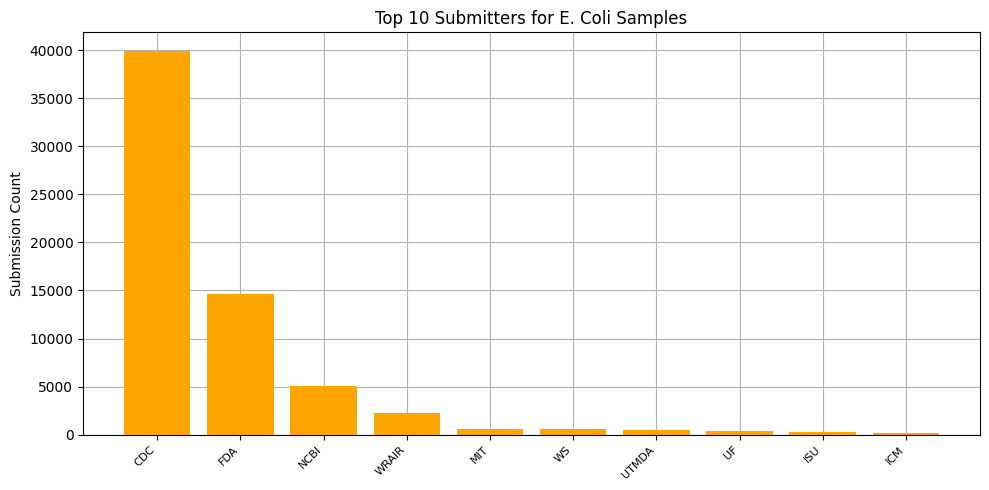

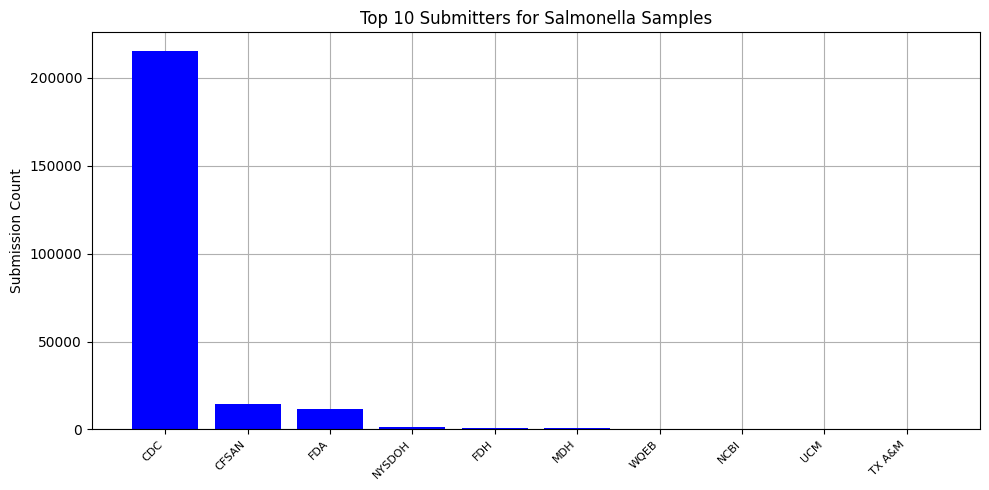

In [202]:
#make a bar chart of the top 10 submitters for each dataset
ecoli_submitters = ecoli['submitter'].value_counts().head(10)
salmonella_submitters = salmonella['submitter'].value_counts().head(10)
#make a bar chart of the top 10 submitters for each dataset
plt.figure(figsize=(10, 5))
plt.bar(ecoli_submitters.index, ecoli_submitters.values, color='orange', label='E. Coli')
plt.title('Top 10 Submitters for E. Coli Samples')
plt.ylabel('Submission Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.gca().set_axisbelow(True)
plt.grid(axis='both')
plt.tight_layout()
plt.savefig('../outputs/top_submitters_ecoli_2009_2023.tiff', dpi=400)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(salmonella_submitters.index, salmonella_submitters.values, color='blue', label='Salmonella')
plt.title('Top 10 Submitters for Salmonella Samples')
plt.ylabel('Submission Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.gca().set_axisbelow(True)
plt.grid(axis='both')
plt.tight_layout()
plt.savefig('../outputs/top_submitters_salmonella_2009_2023.tiff', dpi=400)
plt.show()


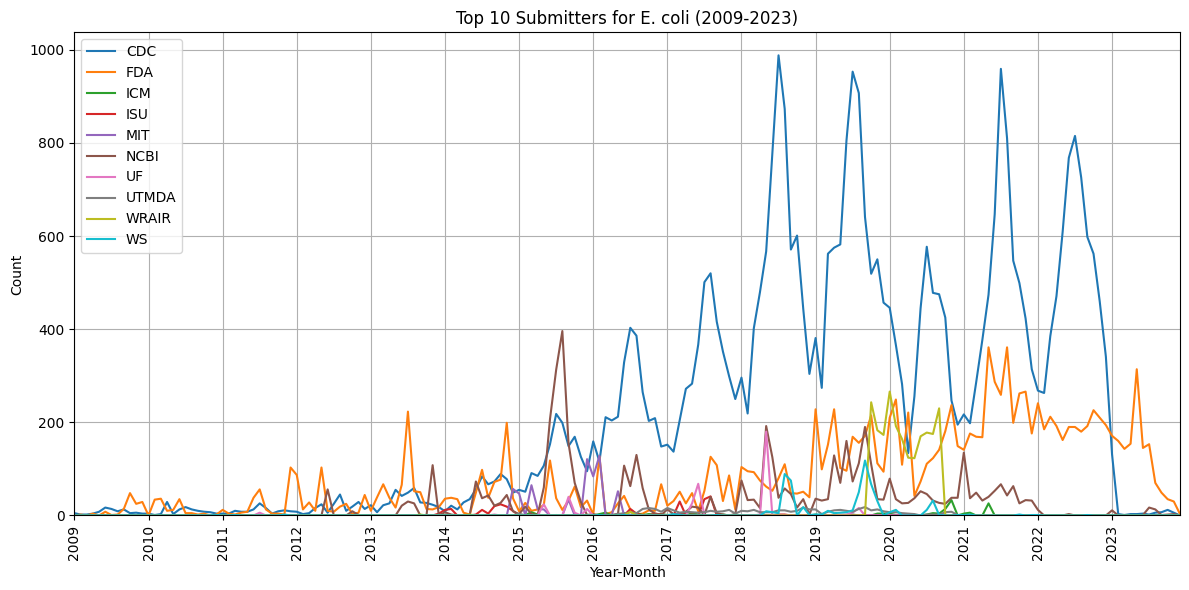

In [203]:
#make a line plot for ecoli_top_10_counts

plt.figure(figsize=(12, 6))
for submitter in ecoli_top_10_counts.columns:
    plt.plot(ecoli_top_10_counts.index, ecoli_top_10_counts[submitter], label=submitter)
plt.xlabel('Year-Month')
plt.ylabel('Count')
plt.title('Top 10 Submitters for E. coli (2009-2023)')
plt.xlim(left='2009-01', right='2023-12')
plt.ylim(bottom=0)
plt.legend()
# Make the xticks only show every 12 months. Don't show the "-01" part on the ticks

plt.xticks(ticks=range(0, len(ecoli_top_10_counts.index), 12), labels=[date[:4] for date in ecoli_top_10_counts.index[::12]], rotation=90)
plt.grid(axis='both')
plt.tight_layout()
plt.savefig('../outputs/top_submitters_ecoli_2009_2023_line.tiff', dpi=400)
plt.show()


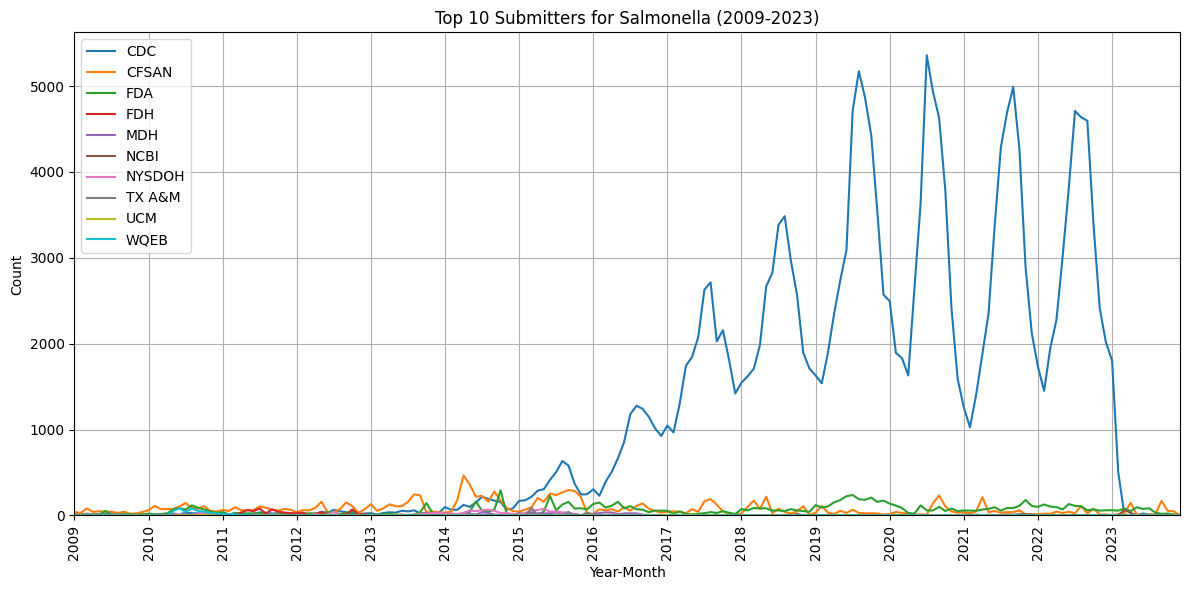

In [204]:
#make a line plot for salmonella_top_10_counts

plt.figure(figsize=(12, 6))
for submitter in salmonella_top_10_counts.columns:
    plt.plot(salmonella_top_10_counts.index, salmonella_top_10_counts[submitter], label=submitter)
plt.xlabel('Year-Month')
plt.ylabel('Count')
plt.title('Top 10 Submitters for Salmonella (2009-2023)')
plt.xlim(left='2009-01', right='2023-12')
plt.ylim(bottom=0)
plt.legend()
# Make the xticks only show every 12 months. Don't show the "-01" part on the ticks

plt.xticks(ticks=range(0, len(salmonella_top_10_counts.index), 12), labels=[date[:4] for date in salmonella_top_10_counts.index[::12]], rotation=90)
plt.grid(axis='both')
plt.tight_layout()
plt.savefig('../outputs/top_submitters_salmonella_2009_2023_line.tiff', dpi=400)
plt.show()